In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

In [2]:


# Set plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# 1. Load Cleaned Dataset
df = pd.read_csv("../Data/Processed/cleaned_reviews.csv")
print(f"Total Records: {len(df):,}")

# Ensure text is string type
df['review'] = df['review'].astype(str)

# 2. Feature Extraction for EDA
df['char_count'] = df['review'].apply(len)
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

# Quick statistical summary
print("\n--- Summary Statistics by Class (0 = Genuine, 1 = Fake) ---")
display(df.groupby('label')[['char_count', 'word_count']].describe().T)

Total Records: 54,403

--- Summary Statistics by Class (0 = Genuine, 1 = Fake) ---


label                        0             1
char_count count  27215.000000  27188.000000
           mean     441.731178    334.397050
           std      442.256478    332.889378
           min        3.000000      1.000000
           25%      135.000000    103.000000
           50%      275.000000    203.000000
           75%      586.000000    433.000000
           max     4159.000000   4075.000000
word_count count  27215.000000  27188.000000
           mean      79.494103     63.775048
           std       77.988124     63.290256
           min        1.000000      1.000000
           25%       25.000000     20.000000
           50%       50.000000     39.000000
           75%      105.000000     82.000000
           max      749.000000    784.000000

# **Visualizations (Class Balance & Length Distribution)**

C:\Users\gssha\AppData\Local\Temp\ipykernel_15216\3643620888.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
C:\Users\gssha\AppData\Local\Temp\ipykernel_15216\3643620888.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Genuine (0)', 'Fake (1)'])


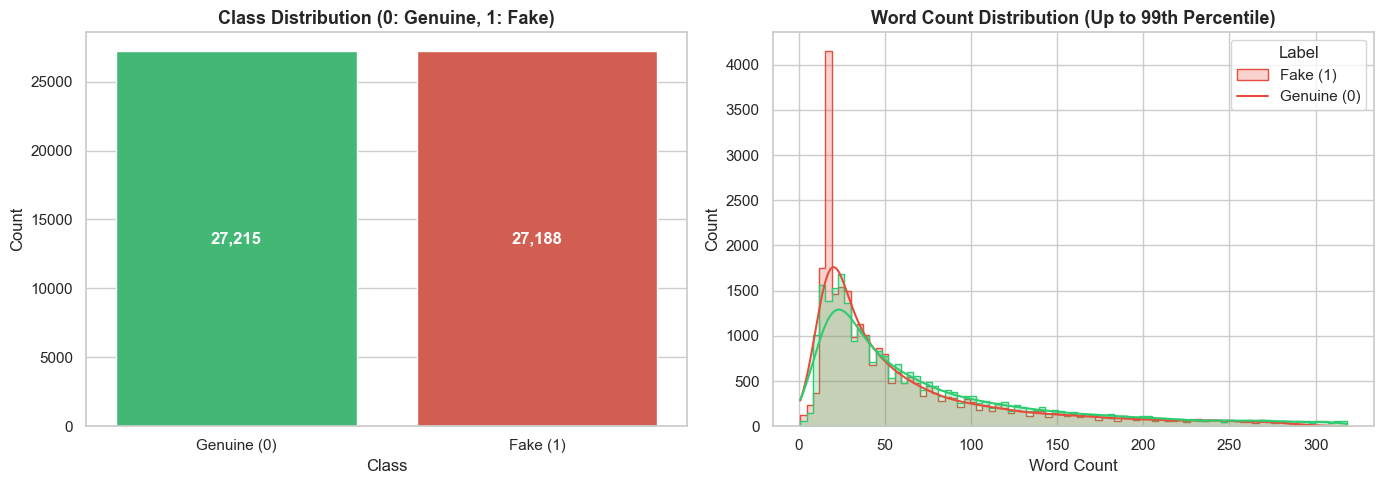

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Class Distribution
sns.countplot(data=df, x='label', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title("Class Distribution (0: Genuine, 1: Fake)", fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['Genuine (0)', 'Fake (1)'])
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

# Add count annotations
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', 
                     (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold')

# Plot B: Word Count Distribution (Clipped at 99th percentile for readability)
max_p99 = int(df['word_count'].quantile(0.99))
sns.histplot(data=df[df['word_count'] <= max_p99], x='word_count', hue='label', 
             kde=True, element='step', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title("Word Count Distribution (Up to 99th Percentile)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Word Count")
axes[1].legend(title='Label', labels=['Fake (1)', 'Genuine (0)'])

plt.tight_layout()
plt.show()

# **Critical Transformer Metric — Sequence Length Percentiles**

In [4]:
# Approximate token length (word count is a solid proxy, typically token_count ≈ word_count * 1.3)
percentiles = [50, 75, 90, 95, 98, 99]
word_percentiles = np.percentile(df['word_count'], percentiles)

print("--- Sequence Length Percentile Analysis ---")
for p, val in zip(percentiles, word_percentiles):
    est_bert_tokens = int(val * 1.3)
    print(f"{p}th Percentile: {int(val)} words (~{est_bert_tokens} BERT subword tokens)")

--- Sequence Length Percentile Analysis ---
50th Percentile: 44 words (~57 BERT subword tokens)
75th Percentile: 93 words (~120 BERT subword tokens)
90th Percentile: 174 words (~226 BERT subword tokens)
95th Percentile: 233 words (~302 BERT subword tokens)
98th Percentile: 284 words (~369 BERT subword tokens)
99th Percentile: 318 words (~413 BERT subword tokens)


# **Top N-Grams (Deceptive vs. Truthful Patterns)**

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n_gram_range, top_k=10):
    """
    Extracts the top_k most frequent n-grams from a text corpus.
    """
    # Initialize CountVectorizer with standard english stopwords
    vec = CountVectorizer(ngram_range=n_gram_range, stop_words='english').fit(corpus)
    
    # Transform the corpus to get counts
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    
    # Map words to their frequency
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    
    return words_freq[:top_k]

# **Top bi-grams**

C:\Users\gssha\AppData\Local\Temp\ipykernel_15216\3623313403.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_fake_bi, x='Count', y='Bigram', ax=axes[0], palette='Reds_r')
C:\Users\gssha\AppData\Local\Temp\ipykernel_15216\3623313403.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_gen_bi, x='Count', y='Bigram', ax=axes[1], palette='Greens_r')


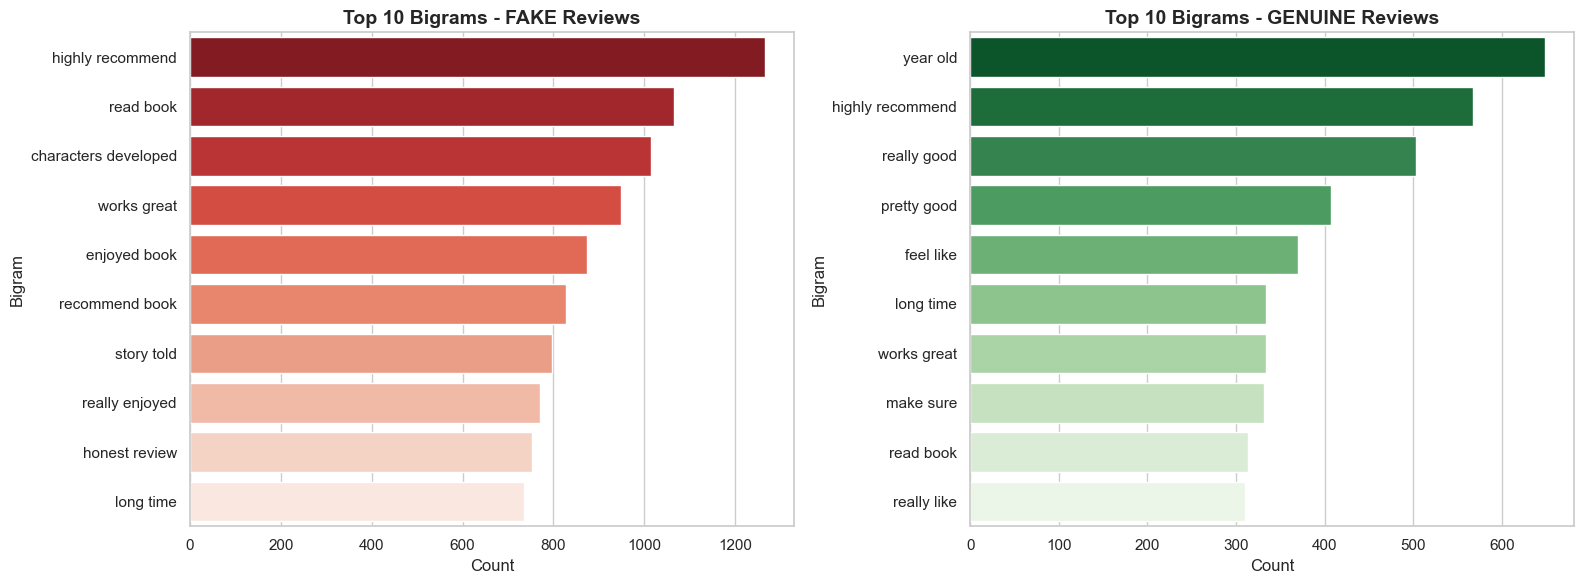

In [9]:
# Separate the text by class
fake_reviews = df[df['label'] == 1]['review'].astype(str)
genuine_reviews = df[df['label'] == 0]['review'].astype(str)

# Extract top 10 bigrams
top_fake_bigrams = get_top_ngrams(fake_reviews, n_gram_range=(2, 2), top_k=10)
top_gen_bigrams = get_top_ngrams(genuine_reviews, n_gram_range=(2, 2), top_k=10)

# Convert to DataFrames for plotting
df_fake_bi = pd.DataFrame(top_fake_bigrams, columns=['Bigram', 'Count'])
df_gen_bi = pd.DataFrame(top_gen_bigrams, columns=['Bigram', 'Count'])

# Plotting Bigrams
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=df_fake_bi, x='Count', y='Bigram', ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 Bigrams - FAKE Reviews', fontweight='bold', fontsize=14)

sns.barplot(data=df_gen_bi, x='Count', y='Bigram', ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Bigrams - GENUINE Reviews', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

# **Top Tri-grams**

C:\Users\gssha\AppData\Local\Temp\ipykernel_15216\1687967847.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_fake_tri, x='Count', y='Trigram', ax=axes[0], palette='Reds_r')
C:\Users\gssha\AppData\Local\Temp\ipykernel_15216\1687967847.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_gen_tri, x='Count', y='Trigram', ax=axes[1], palette='Greens_r')


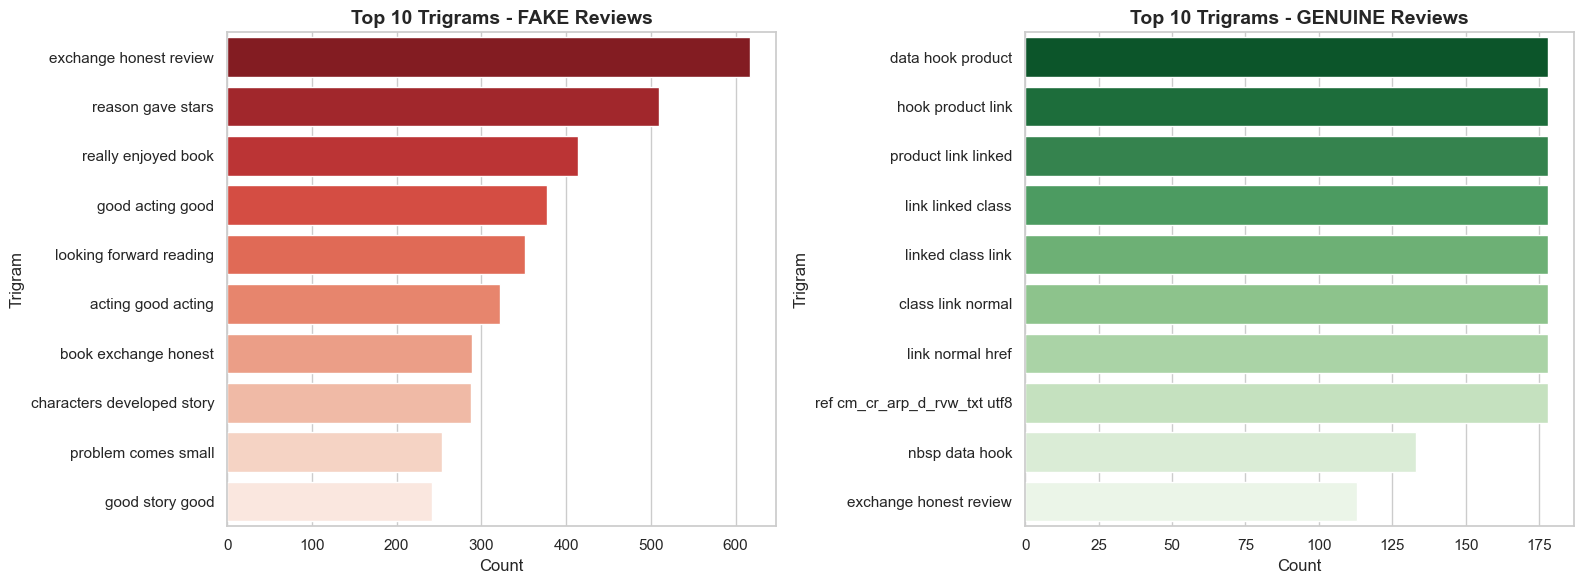

In [10]:
# Extract top 10 trigrams
top_fake_tri = get_top_ngrams(fake_reviews, n_gram_range=(3, 3), top_k=10)
top_gen_tri = get_top_ngrams(genuine_reviews, n_gram_range=(3, 3), top_k=10)

df_fake_tri = pd.DataFrame(top_fake_tri, columns=['Trigram', 'Count'])
df_gen_tri = pd.DataFrame(top_gen_tri, columns=['Trigram', 'Count'])

# Plotting Trigrams
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=df_fake_tri, x='Count', y='Trigram', ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 Trigrams - FAKE Reviews', fontweight='bold', fontsize=14)

sns.barplot(data=df_gen_tri, x='Count', y='Trigram', ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Trigrams - GENUINE Reviews', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

# **Word-Cloud**
- ### Visualizing the most prominent words in each class 

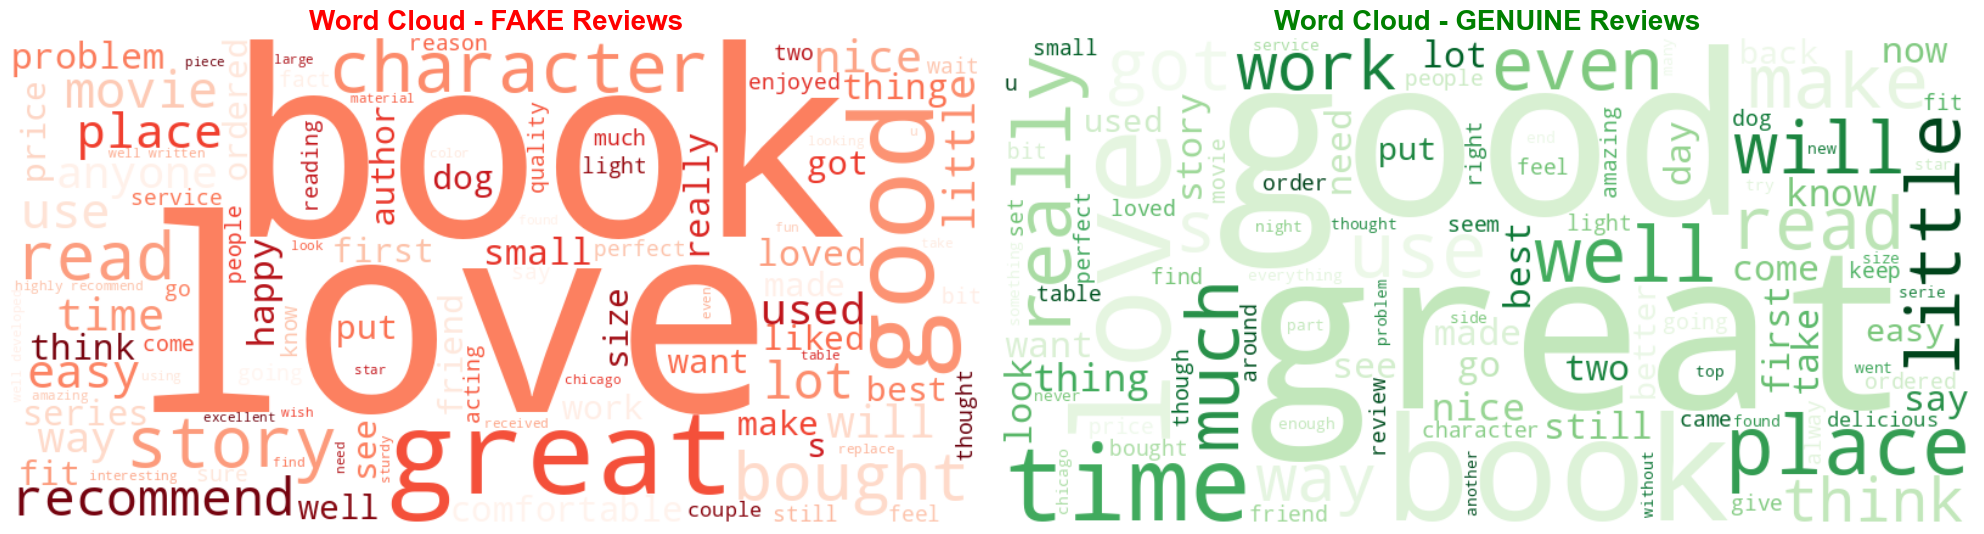

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# 1. Load the cleaned dataset if not already in memory
# df = pd.read_csv("../Data/Processed/cleaned_reviews.csv")

# 2. Add custom stopwords to filter out generic terms (optional but recommended)
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(["hotel", "restaurant", "product", "room", "food", "one"]) 

# 3. Combine text by class
fake_text = " ".join(review for review in df[df['label'] == 1]['review'].astype(str))
genuine_text = " ".join(review for review in df[df['label'] == 0]['review'].astype(str))

# 4. Generate Word Clouds
wordcloud_fake = WordCloud(
    width=800, height=400, 
    background_color='white', 
    stopwords=custom_stopwords, 
    colormap='Reds', # Red tint for fake
    max_words=100
).generate(fake_text)

wordcloud_genuine = WordCloud(
    width=800, height=400, 
    background_color='white', 
    stopwords=custom_stopwords, 
    colormap='Greens', # Green tint for genuine
    max_words=100
).generate(genuine_text)

# 5. Plot the Word Clouds side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(wordcloud_fake, interpolation='bilinear')
axes[0].set_title('Word Cloud - FAKE Reviews', fontsize=20, fontweight='bold', color='red')
axes[0].axis('off')

axes[1].imshow(wordcloud_genuine, interpolation='bilinear')
axes[1].set_title('Word Cloud - GENUINE Reviews', fontsize=20, fontweight='bold', color='green')
axes[1].axis('off')

plt.tight_layout()
plt.show()